# **ANÁLISIS DE DATOS EXPLORATORIO**

Para saber con qué tipo de datos estoy trabajando, qué puedo mostrar en el dashboard y cuál es la información que realmente me ayudará a tomar mejores decisiones financieras al momento de invertir, primero haré un análisis exploratorio sobre los datos que da Yahoo Finance y las acciones de las diferentes empresas y su impacto global.

In [1]:
# Import de librerías necesarias
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize

In [2]:
# Los tickers son símbolos bursátiles. Es el código corto que identifica a una acción en la bolsa de valores.
tickers = ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'META', 'NVDA']

data = yf.download(tickers=tickers, period="2y", auto_adjust=True, progress=False)
# Obtiene los precios de cierre para poder graficarlos
prices = data["Close"]
prices.tail() # Muestra los últimos 5 registros de cada ticker

Ticker,AAPL,AMZN,GOOG,META,MSFT,NVDA
Date,,,,,,
2026-06-01,306.309998,261.260010,372.579987,600.469971,460.519989,224.098816
2026-06-02,315.200012,256.519989,358.390015,597.630005,441.309998,222.560608
2026-06-03,310.260010,250.020004,355.679993,622.979980,427.339996,214.500000
2026-06-04,311.230011,253.789993,369.269989,627.570007,428.049988,218.660004
2026-06-05,307.339996,246.029999,365.760010,593.000000,416.670013,205.100006


### **Retornos, Volatilidad y Sharpe ratio**

En un primer vistaso a como se comportan las acciones mediré la volatilidad (riesgo), junto con el retorno que me ofrece cada entidad para ver de primera mano, que inversión a las empresas que elegí se vuelve mejor.

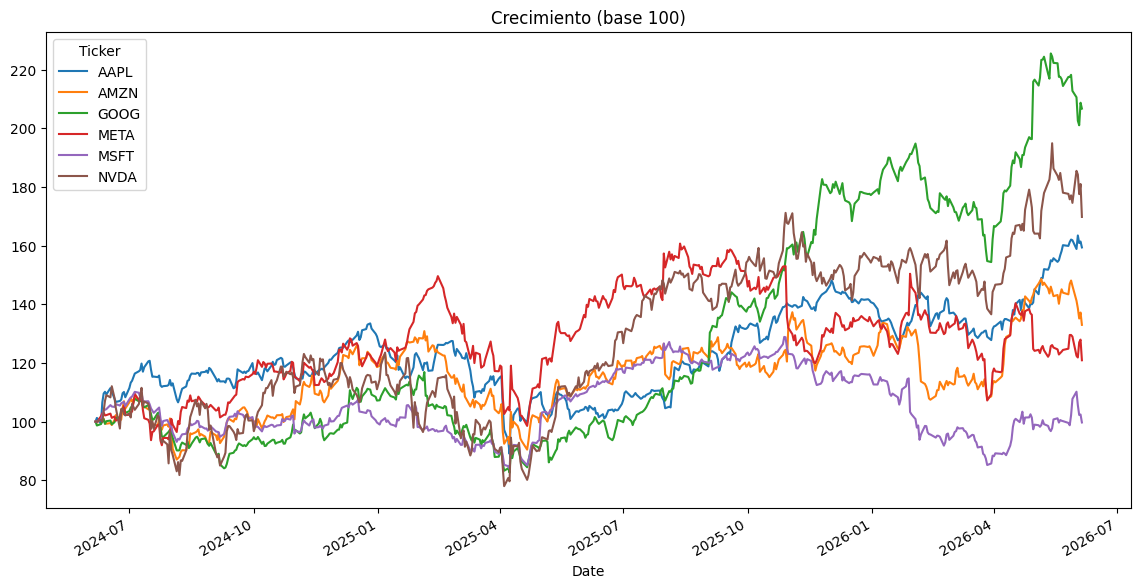

In [3]:
# Grafica los precios de cierre de los dos últimos años de cada empresa
(prices / prices.iloc[0] * 100).plot(figsize=(14, 7), title="Crecimiento (base 100)") 
# Se pone en base 100 para que desde el día 1 que se compare, cada uno muestre cuanto creció en porcentaje y no en precio
plt.show()

In [4]:
# A primer ojo veo que los picos de todas son variables y lo que realmente importa no es cuántos picos hubieron, si no la distancia entre c/u
returns = prices.pct_change().dropna()
vol_anual = returns.std() * (252 ** 0.5) # 252 porque son los días al año que trabaja el mercado
print(vol_anual.sort_values(ascending=False))

Ticker
NVDA    0.481721
META    0.363688
AMZN    0.324888
GOOG    0.301910
AAPL    0.282990
MSFT    0.254296
dtype: float64


Noté que aunque hay muchos picos en todas de las gráficas, lo que realmente importa es que tanta distancia hay entre cada uno de esos picos. El número que proporciona esa variable es "vol_anual" y devuelve la votilidad anual de cada ticker que se elige, siendo NVDA el más riesgoso y MSFT el menos riesgoso ya que sus picos se mantuvieron en un rango similar, pero en NVDA se dispararon en ciertos momentos.

Viendo en donde termina cada gráfica a día 05/06/2026; GOOGLE terminó en primer lugar, y aunque NVIDIA tuvo mucho riesgo, con el siguiente código se detecta si valió la pena semejante riesgo de 48% o GOOGLE ganó más con menos sustos.

In [5]:
# Cómo se comporta el Sharpe Ratio: Retorno por cada unidad de riesgo. Es la métrica que separa el "ganó mucho" a la de "ganó bien"
ret_anual = returns.mean() * 252
print(ret_anual.sort_values(ascending=False))

# Cálculo del Sharpe = (retorno-rf)/volatilidad donde rf es la tasa libre de riesgo
rf = 0.04
sharpe = (ret_anual-rf) / vol_anual
print(sharpe.sort_values(ascending=False))

Ticker
GOOG    0.411559
NVDA    0.382983
AAPL    0.274702
AMZN    0.196311
META    0.161395
MSFT    0.030770
dtype: float64
Ticker
GOOG    1.230695
AAPL    0.829365
NVDA    0.711995
AMZN    0.481122
META    0.333789
MSFT   -0.036298
dtype: float64


Con esto pude darme cuenta que GOOGLE no solo ganó más de 41% si no que además lo hizo eficientemente. Por lo tanto puedo considerarla una buena relación retorno/riesgo. 

NVIDIA en retorno fue el segundo con 38%, en Sharpe cae a 3ra debajo de APPLE, porque su volatilidad de 48% se lo come. Por ello APPLE fue mejor inversión ajustada por riesgo.

MICROSOFT en negativo es una señal clara de ganar poco y con mucho más riesgo de lo que productos libres de riesgo pueden darte, esto la convierte en la peor inversión que puedo hacer de las 6.

### **Matriz de Correlaciones - Diversificación**

La correlación mide qué tan juntas se mueven dos acciones, de -1 a +1. Alto (~+1) = bailan igual; bajo o negativo = se compensan. Y combinar acciones que NO se mueven igual es lo que reduce riesgo sin sacrificar tanto retorno — eso es **diversificar**, buscar acciones que no tengan mucho que ver la una con la otra para de esa manera no tener un riesgo similar en cada producto.

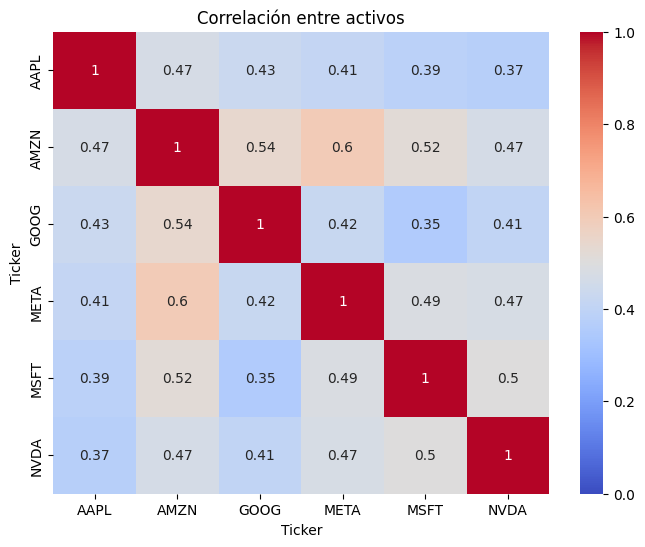

In [6]:
# Creación de la variable para ver la correlación
corr = returns.corr()

# Mapa de calor
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=0, vmax=1)
plt.title("Correlación entre activos")
plt.show()

La matriz dice que tanta correlación existe entre una y otra empresa en sus retornos. Aunque hay correlaciones menos fuertes que otras, no debe sorprender que la menor aún sigue acercándose más a 1 que a -1 y esto se debe a que las empresas elegidas pertenecen a la misma área tecnológica y gringa.

Aunque en empresas de la misma área, un valor como 0.5 hasta se queda bajo y números como 0.35 a 0.60 son "moderados para ser todas empresas tech". No están tan pegadas pero tampoco diversifican bien. Si las 6 se mueven juntas (correlación alta), cuando el sector tech caiga, caen las 6 a la vez — la "diversificación" es una ilusión. Es como tener 6 paraguas para la misma tormenta. **Diversificar de verdad = activos que reaccionan distinto a lo mismo**.

Con esto en mente, ahora se cuestiona lo siguiente: ¿existe una combinación (qué % en cada acción) que de una mejor relación retorno/riesgo que cualquier acción sola? La respuesta la da la optimización de portafolio por medio de la **frontera eficiente de Markowitz**

### **Frontera de Markowitz y simulación Montecarlo**
Una cartera (portafolio) es repartir mi dinero entre las acciones asignándole un peso a cada una. Por ejemplo: 20% en AAPL, 30% en GOOG, 10% en NVDA, etc. La única regla es que los pesos sumen 100% (todo mi dinero está invertido).

Cada combinación distinta de pesos es una cartera distinta, con su propio retorno y su propio riesgo.

**Retorno de la cartera** — es el promedio ponderado de los retornos:

$$\mu_p = \sum_i w_i \, \mu_i$$

Es decir, el retorno de cada acción multiplicado por su peso, todo sumado.

**Riesgo de la cartera** — aquí está lo interesante:

$$\sigma_p = \sqrt{w^T \Sigma \, w}$$

donde $\Sigma$ es la matriz de covarianzas entre las acciones. Lo importante y contraintuitivo: el riesgo de la cartera **NO** es el promedio de los riesgos individuales. Normalmente es **menor**, porque cuando se combinan acciones que no se mueven exactamente igual, sus movimientos se cancelan parcialmente y el riesgo total baja. Ese término con la matriz de covarianzas es, matemáticamente, la diversificación. Por eso antes calculé las correlaciones: esa estructura es el ingrediente que hace que ciertas combinaciones sean mejores que sus partes.

Si calculo el riesgo y el retorno de miles de carteras con pesos aleatorios y las grafico (riesgo en el eje X, retorno en el eje Y), forman una nube con forma de bala o sombrilla.

El borde superior izquierdo de esa nube es la **frontera eficiente**: son las carteras óptimas, las que dan el máximo retorno posible para cada nivel de riesgo. Cualquier cartera por debajo de ese borde es subóptima, porque para el mismo riesgo existe otra que rinde más.

**¿Cómo lo voy a construir?**
En lugar de resolverlo con optimización matemática exacta, voy a simular miles de carteras con pesos al azar y calcular el retorno y riesgo de cada una. Es más intuitivo y me deja **ver** cómo se forma la nube. El plan:

1. Calcular la matriz de covarianzas anualizada.
2. Hacer una función que reciba pesos y devuelva (retorno, riesgo) de la cartera.
3. Simular miles de carteras con pesos aleatorios.
4. Graficar la nube, coloreada por Sharpe ratio, para ver la frontera.
5. Marcar la mejor cartera (la de mayor Sharpe) en la gráfica.

In [7]:
# Variable para la covarianza anualizada
cov_anual = returns.cov() * 252
cov_anual

Ticker,AAPL,AMZN,GOOG,META,MSFT,NVDA
Ticker,,,,,,
AAPL,0.080083,0.043280,0.036882,0.042508,0.027780,0.050813
AMZN,0.043280,0.105552,0.052961,0.070841,0.042902,0.073287
GOOG,0.036882,0.052961,0.091150,0.046404,0.027052,0.058928
META,0.042508,0.070841,0.046404,0.132269,0.044945,0.082972
MSFT,0.027780,0.042902,0.027052,0.044945,0.064667,0.061435
NVDA,0.050813,0.073287,0.058928,0.082972,0.061435,0.232055


Covarianza mide, igual que la correlación, si dos activos se mueven juntos, pero sin normalizar a [-1, 1]. O sea, la covarianza mezcla dos cosas en un solo número: qué tanto se mueven juntos y qué tan volátil es cada uno. La correlación es la covarianza "limpia" (dividida entre las volatilidades) para que quede entre -1 y 1.

In [8]:
# Función que reciba pesos y devuelva (retorno, riesgo) de esa cartera
def metricas_cartera(pesos, ret_anual, cov_anual):
    pesos = np.array(pesos)
    retorno = np.sum(pesos * ret_anual) # retorno ponderado
    riesgo = np.sqrt(pesos.T @ cov_anual @ pesos) # raíz de wᵀ Σ w
    return retorno, riesgo

# Prueba con cartera de ejemplo
pesos_iguales = [1/6] * 6
ret, rie = metricas_cartera(pesos_iguales, ret_anual, cov_anual)
print(f"Retorno de la cartera: {ret:.4f} \nRiesgo de la cartera: {rie:.4f}")

Retorno de la cartera: 0.2430 
Riesgo de la cartera: 0.2490


Como primer ejemplo se hizo la combinación en pesos iguales de las 6 acciones y el riesgo total quedó por debajo del promedio simple de las 6 volatilidades individuales (28, 25, 30, 36, 25, 48) es ≈ 32%. Y la cartera dio **24.9%**

24.9% es *más bajo que la acción menos riesgosa individual* (MSFT y AAPL, ~25%). O sea, la cartera completa es **tan tranquila como la acción más tranquila, pero ganando 24.3% de retorno** en vez del mísero 3% de MSFT. Los movimientos de las acciones se cancelaron parcialmente entre sí, y el riesgo se desplomó.

**NADIE SERIO EN INVERSIONES INVIERTE EN UNA SOLA ACCIÓN**

Ahora toca simular las carteras con pesos aleatorios y calcular retorno/riesgo de cada una para después graficar la nube.

In [9]:
np.random.seed(42) # fijamos semilla para que siempre arroje el mismo resultado

n_carteras = 10000
n_activos = len(ret_anual)

resultados = np.zeros((3, n_carteras)) # fila 0: retorno, fila 1: riesgo, fila 2: sharpe
pesos_guardados = []

rf = 0.04

for i in range(n_carteras):
    pesos = np.random.random(n_activos) # pesos al azar
    pesos /= np.sum(pesos) # normalizar para que sumen 1 (100%)
    pesos_guardados.append(pesos)
    
    ret, rie = metricas_cartera(pesos, ret_anual, cov_anual)
    resultados[0, i] = ret
    resultados[1, i] = rie
    resultados[2, i] = (ret-rf)/rie # sharpe
    
print("Listo:", n_carteras, "carteras simuladas")
print("Sharpe máximo encontrado:", resultados[2].max().round(5))

Listo: 10000 carteras simuladas
Sharpe máximo encontrado: 1.23432


1er Sharpe de la mejor cartera: 1.215.<br>
2do Sharpe de la mejor cartera: 1.248. <br>
3er Sharpe de la mejor cartera: 1.2343 <br>
Sharpe de GOOG sola: 1.231. 
Casi idénticos, GOOG en dos por arriba y en otra por abajo, y eso concluye dos cosas:

1. Que estén tan pegados ya es revelador. Una cartera diversificada (riesgo repartido en 6) alcanzó casi el mismo premio-por-riesgo que la mejor acción individual — pero con muchísimo menos riesgo de estar mal. GOOG-sola depende 100% de que GOOG siga brillando; si Google tropieza, se hunde todo. La cartera da casi el mismo Sharpe sin esa fragilidad. Aun "empatando", la cartera es la apuesta más inteligente.

2. Y aquí está el matiz técnico que probablemente explica el "no le ganó": np.random.random() da pesos parejos — tienden a repartir entre las 6 acciones de forma relativamente balanceada. Para ganarle a GOOG en Sharpe, la cartera óptima seguramente necesita cargar muchísimo a GOOG (digamos 60-70% en GOOG y poquito en las demás). Pero pesos al azar rara vez generan algo tan extremo como "70% en una sola" — la aleatoriedad uniforme casi nunca propone carteras tan concentradas. O sea: puede que la cartera ganadora exista, pero Monte Carlo no la encontró porque no "tiró el dado" en esa esquina extrema.

Esa es una limitación real del método Monte Carlo, y es oro descubrirlo: explorar al azar no garantiza encontrar el óptimo verdadero, sobre todo si vive en una esquina rara del espacio. 

In [10]:
# Encuentra los pesos de la mejor cartera
idx_mejor = resultados[2].argmax() # posición de la cartera con mayor sharpe
pesos_mejor = pesos_guardados[idx_mejor]

for ticker, peso in zip(ret_anual.index, pesos_mejor):
    print(f"{ticker}: {peso:.1%}")

print(f"\nRetorno: {resultados[0, idx_mejor]:.1%}")
print(f"Riesgo:  {resultados[1, idx_mejor]:.1%}")
print(f"Sharpe:  {resultados[2, idx_mejor]:.3f}")

# ¿La estrella  que se coloca en la gráfica coincide con lo que hay en resultados?
idx = resultados[2].argmax()
print("Desde resultados[]  -> Retorno:", round(resultados[0, idx], 4),
    "Riesgo:", round(resultados[1, idx], 4),
    "Sharpe:", round(resultados[2, idx], 4))
print("Máx retorno en toda la nube:", round(resultados[0].max(), 4))


AAPL: 12.2%
AMZN: 2.2%
GOOG: 62.6%
META: 1.8%
MSFT: 0.1%
NVDA: 21.1%

Retorno: 37.9%
Riesgo:  27.5%
Sharpe:  1.234
Desde resultados[]  -> Retorno: 0.3792 Riesgo: 0.2748 Sharpe: 1.2343
Máx retorno en toda la nube: 0.3792


La cartera ganadora es básicamente "GOOG con un poco de AAPL (12.2%) y migajas de las demás". AMZN, MSFT, NVDA casi en cero — el optimizador (bueno, el azar) las descartó porque tenían peor Sharpe individual.

Monte Carlo da resultados distintos cada corrida (aleatorio). Fijar np.random.seed() para reproducibilidad. El óptimo del MC es aproximado, no exacto — para el exacto se usa optimización (scipy)

Si un punto parece fuera de la nube, se verifica numéricamente antes de asumir bug. Calcular datos que se grafican juntos en la misma celda evita desincronización. El máximo retorno de la simulación coincide con la estrella → todo consistente.

La nube se grafica como:

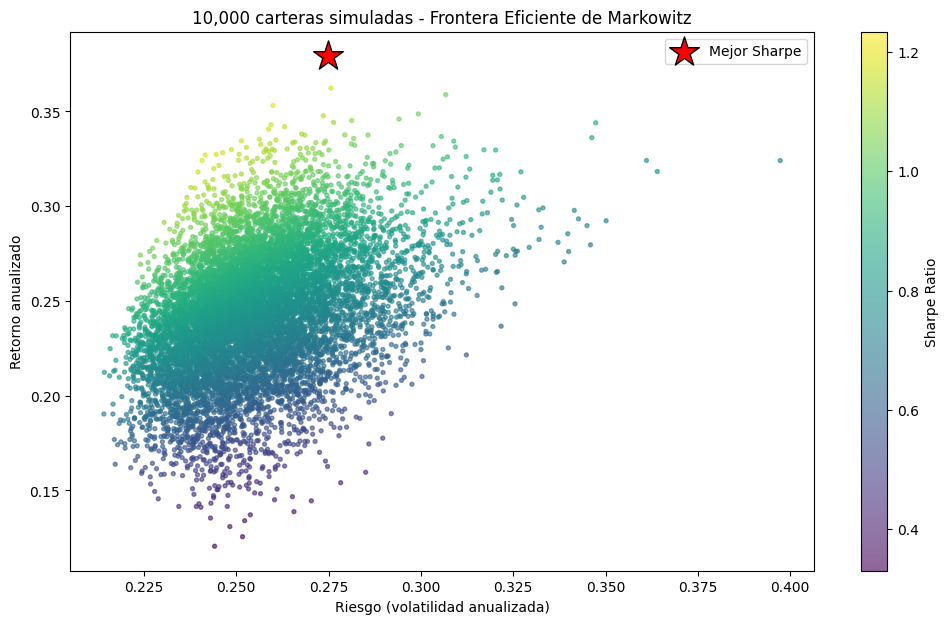

In [11]:
plt.figure(figsize=(12,7))

# Cada cartera se toma como un punto: riesgo en X, retorno en Y, color = Sharpe
sc = plt.scatter(resultados[1], resultados[0],
                c=resultados[2], cmap="viridis", s=8, alpha=0.6)
plt.colorbar(sc, label="Sharpe Ratio")

# Marca la mejor cartera (Mayor Sharpe) con una estrella roja
idx_mejor = resultados[2].argmax()
plt.scatter(resultados[1, idx_mejor], resultados[0, idx_mejor],
            c="red", marker="*", s=500, edgecolors="black",
            label="Mejor Sharpe", zorder=5)

plt.xlabel("Riesgo (volatilidad anualizada)")
plt.ylabel("Retorno anualizado")
plt.title("10,000 carteras simuladas - Frontera Eficiente de Markowitz")
plt.legend()
plt.show()

Con la gráfica se pueden notar ciertas cosas:

- La forma de bala/sombrilla ladeada hacia arriba-derecha.
- El gradiente de color cuenta la historia: amarillo/verde (Sharpe alto) arriba a la izquierda; morado (Sharpe bajo) abajo a la derecha. O sea, las buenas carteras (mucho retorno, poco riesgo) están arriba-izquierda; las tontas (poco retorno, mucho riesgo) abajo-derecha. Exactamente como debe ser.
- La frontera eficiente es ese borde amarillo del filo superior-izquierdo. Esas son las carteras óptimas.
- La "pared" izquierda (~0.21 de riesgo) es el límite de diversificación — no se puede bajar de ahí combinando estas 6.

### **Optimización**

Ahora, la idea: en vez de probar 10,000 al azar, un optimizador busca dirigidamente los pesos que maximizan el Sharpe — recorre la superficie cuesta arriba hasta la cima. Garantiza el óptimo (o muy cerca), es reproducible, y no depende de suerte.

Un optimizador necesita 3 cosas, siempre:

1. Función objetivo → el número que quieres minimizar. Aquí se busca maximizar el Sharpe… pero los optimizadores solo saben minimizar. Truco estándar: minimizar el Sharpe negativo (minimizar -Sharpe = maximizar Sharpe). Mismo resultado, volteado.
2. Restricciones (constraints) → reglas que la solución DEBE cumplir. La solución en este caso: los pesos suman 100% (sum(pesos) = 1). No se puede invertir 120% del dinero.
3. Límites (bounds) → rango de cada peso. Aquí: cada peso entre 0 y 1 (0% a 100%). El límite inferior en 0 significa "no short-selling" — no se puede tener peso negativo (apostar a que una acción baje). Solo posiciones normales.

Un optimizador es como un excursionista con los ojos vendados buscando la cima de una montaña. Solo puede sentir la pendiente bajo sus pies y dar pasos cuesta arriba. Para mandarlo a trabajar, necesitas decirle 3 cosas: qué montaña escalar (función objetivo), qué reglas no puede romper (restricciones) y por dónde tiene permiso de caminar (límites). Vamos una por una.

In [12]:
# 1. Función objetivo: Sharpe NEGATIVO (minimizar -Sharpe = maximizar Sharpe)
def sharpe_negativo(pesos, ret_anual, cov_anual, rf=0.04):
    ret, rie = metricas_cartera(pesos, ret_anual, cov_anual)
    return -(ret - rf) / rie

# 2. Restricciones: los pesos suman 1
restricciones = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})

# 3. Límites: cada peso entre 0 y 1 (sin short-selling)
limites = tuple((0, 1) for _ in range(n_activos))

# Punto de arranque: pesos iguales
pesos_iniciales = np.array([1/n_activos] * n_activos)

# Optimizar
optimo = minimize(sharpe_negativo, pesos_iniciales,
                args=(ret_anual, cov_anual),
                method='SLSQP',
                bounds=limites,
                constraints=restricciones)

pesos_optimos = optimo.x

# Se muestran resultados
ret_opt, rie_opt = metricas_cartera(pesos_optimos, ret_anual, cov_anual)
sharpe_opt = (ret_opt - rf) / rie_opt

print("=== CARTERA ÓPTIMA (exacta) ===")
for ticker, peso in zip(ret_anual.index, pesos_optimos):
    print(f"{ticker}: {peso:.1%}")
print(f"\nRetorno: {ret_opt:.1%}  Riesgo: {rie_opt:.1%}  Sharpe: {sharpe_opt:.3f}")

=== CARTERA ÓPTIMA (exacta) ===
AAPL: 23.3%
AMZN: 0.0%
GOOG: 69.1%
META: 0.0%
MSFT: 0.0%
NVDA: 7.6%

Retorno: 37.7%  Riesgo: 26.3%  Sharpe: 1.284


Comparativa completa del viaje:

El óptimo exacto ganó a los dos. 1.284 > 1.234 > 1.231. Y la diferencia sobre el Monte Carlo (1.234 → 1.284) no es ruido — es justo lo que se predijo: el azar rodeó la cima pero no la clavó; scipy subió derecho hasta arriba. Se confirma con números por qué la optimización exacta > Monte Carlo.
Los pesos óptimos cuentan la historia fina:

- GOOG 69.1% — manda aún más que en el Monte Carlo (62.6%). La hipótesis original ("para ganar hay que cargar fuerte a GOOG") se cumplió al extremo.
- AAPL 23.3% — el segundo, la otra de buen Sharpe individual.
- NVDA 7.6% — poquito. Curioso: NVDA tiene buen retorno, pero su riesgo de 48% hace que el optimizador la quiera solo en dosis chica.
- AMZN, META, MSFT: 0.0% — el optimizador las descartó por completo. No aportan al mejor Sharpe (peor relación retorno/riesgo o muy -
correlacionadas con las que ya están). Esto es elegante: la matemática "decidió" que ni vale la pena tenerlas.

Esos ceros son una lección de oro: diversificar no es meter de todo. El óptimo concentró en 3 activos y tiró 3. Más activos ≠ mejor cartera — lo que importa es la combinación retorno/riesgo/correlación, no la cantidad

### **Conexión con la teoría: optimización con restricciones**

Lo que se acaba de resolver con scipy es, formalmente, un **problema de optimización con restricciones** — el mismo tipo que se ve en optimización / investigación de operaciones. Escrito en lenguaje matemático:

$$\max_{w} \ \frac{w^T\mu - r_f}{\sqrt{w^T\Sigma\, w}} \quad \text{sujeto a} \quad \sum_i w_i = 1, \quad 0 \le w_i \le 1$$

Donde cada parte corresponde a algo del código:

- **Función objetivo** $\dfrac{w^T\mu - r_f}{\sqrt{w^T\Sigma w}}$ → el Sharpe ratio que se quiere maximizar. (En el código lo minimizo con signo negativo, porque scipy solo minimiza.)
- **Restricción de igualdad** $\sum_i w_i = 1$ → los pesos suman 100% (todo el dinero invertido). En scipy la escribí como `np.sum(w) - 1 = 0`.
- **Límites (desigualdades)** $0 \le w_i \le 1$ → cada peso entre 0% y 100%. El piso en 0 prohíbe el short-selling.

scipy resuelve esto numéricamente (con el método SLSQP) lo que académicamente se resolvería analíticamente con **multiplicadores de Lagrange / condiciones KKT**. Es decir: la misma matemática de optimización con restricciones de mi carrera, aplicada a datos reales y a mi propio dinero.

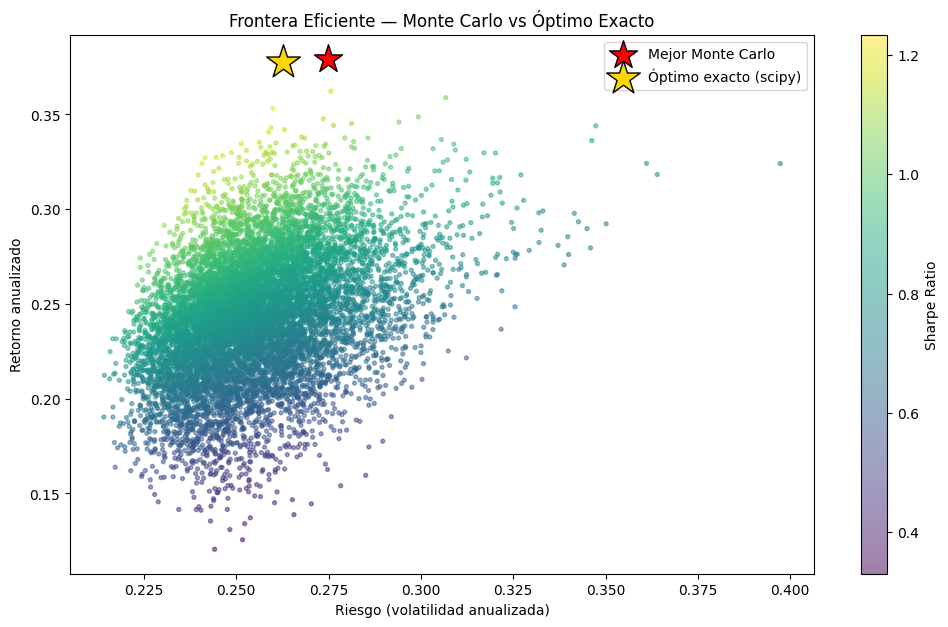

Monte Carlo -> Riesgo: 27.5%  Retorno: 37.9%
Óptimo exacto -> Riesgo: 26.3%  Retorno: 37.7%


In [13]:
# Grafica con estrellas alusivas a la comparación de MONTE CARLO y OPTIMIZACIÓN
opt_ret, opt_rie = metricas_cartera(pesos_optimos, ret_anual, cov_anual)
idx_mejor = resultados[2].argmax()
mc_ret, mc_rie = resultados[0, idx_mejor], resultados[1, idx_mejor]

# ── Gráfica ──
plt.figure(figsize=(12, 7))
sc = plt.scatter(resultados[1], resultados[0],
                c=resultados[2], cmap="viridis", s=8, alpha=0.5)
plt.colorbar(sc, label="Sharpe Ratio")

# Estrellas
plt.scatter(mc_rie, mc_ret, c="red", marker="*", s=450,
            edgecolors="black", label="Mejor Monte Carlo", zorder=5)
plt.scatter(opt_rie, opt_ret, c="gold", marker="*", s=650,
            edgecolors="black", label="Óptimo exacto (scipy)", zorder=6)

plt.xlabel("Riesgo (volatilidad anualizada)")
plt.ylabel("Retorno anualizado")
plt.title("Frontera Eficiente — Monte Carlo vs Óptimo Exacto")
plt.legend()
plt.show()

print(f"Monte Carlo -> Riesgo: {mc_rie:.1%}  Retorno: {mc_ret:.1%}")
print(f"Óptimo exacto -> Riesgo: {opt_rie:.1%}  Retorno: {opt_ret:.1%}")

Estrella dorada (óptimo exacto) está a la izquierda de la roja — mismo retorno (~0.378), pero menos riesgo (~0.263 vs ~0.275 de la roja).
O sea: el óptimo de scipy logró el mismo retorno con menos riesgo → mejor Sharpe. Justo lo que decían los números (1.284 vs 1.234). La gráfica lo confirma visualmente

### **VaR (Value at Risk)**

Hasta ahora se midió riesgo con volatilidad (desviación estándar). Pero la volatilidad tiene un defecto; trata igual un movimiento hacia arriba que hacia abajo. Y a los inversionistas, no les asusta ganar mucho — les asusta perder. La volatilidad mezcla las dos. El VaR se enfoca solo en lo que importa para el miedo: ¿cuánto se puede perder?

"Con X% de confianza, ¿cuánto es lo MÁXIMO que puedo perder en un día (o periodo)?"

**Ejemplo**: un VaR al 95% de -3% significa:

"El 95% de los días, mi pérdida NO será peor que 3%.", O dicho al revés (y aquí está el matiz): "el 5% de los días —1 de cada 20— puedo perder 3% o más."

⚠️ La trampa clásica:

El VaR dice el umbral del mal día… pero NO te dice qué tan malo puede ser cuando se rebasa.
IDEA: "el 5% de los días pierdo 3% o más". ¿Cuánto más? ¿3.1%? ¿40%? El VaR se queda callado. Dice dónde empieza el desastre, no qué tan hondo es el hoyo. Y en mercados con colas pesadas ese hoyo puede ser brutal. El VaR fue muy criticado tras 2008 precisamente por esto: daba falsa tranquilidad ("solo perderás 3% en el peor 5%") y luego venía un día de -20% que el VaR no describía.

La métrica que sí mira dentro de la cola —el promedio de las pérdidas cuando superas el VaR— se llama **CVaR (o Expected Shortfall)**, y es la que un actuario prefiere porque captura el tamaño del desastre, no solo su frecuencia. Pero primero el VaR, y el CVaR cae solito después.

In [14]:
# VaR histórico al 95% para Google
nivel = 5
var_95_goog = np.percentile(returns["GOOG"], nivel)
print(f"VaR histórico 95% (GOOG): {var_95_goog:.4f}  ({var_95_goog:.2%})")

VaR histórico 95% (GOOG): -0.0260  (-2.60%)


Qué hace np.percentile(datos, 5): ordena todos los retornos diarios de GOOG de menor a mayor y devuelve el valor que deja el 5% peor por debajo. Ese número —negativo— es el VaR.
Cómo leer el resultado: si sale, digamos, -0.0260, se lee:

"El 95% de los días, GOOG no pierde más de 2.60%. Pero 1 de cada 20 días (el 5%), puede perder 2.60% o más."

Ese número es una pérdida diaria (retorno de un día). Negativo = pérdida, lógico.

In [15]:
# CVaR 95% para GOOG: promedio de las pérdidas peores que el VaR
cvar_95_goog = returns["GOOG"][returns["GOOG"] <= var_95_goog].mean()
print(f"CVaR histórico 95% (GOOG): {cvar_95_goog:.4f}  ({cvar_95_goog:.2%})")

CVaR histórico 95% (GOOG): -0.0396  (-3.96%)


VaR 95% (GOOG): -2.60% → "el peor 5% de los días empieza en una caída de 2.6%"
CVaR 95% (GOOG): -3.96% → "pero cuando caes en ese peor 5%, en promedio se pierde 3.96%"

Esa brecha de 1.36 puntos (de -2.6% a -3.96%) es el peligro escondido en la cola. El VaR decía "los días malos son de -2.6%". El CVaR destapa que dentro de esos días malos, el promedio real es casi 4% — un 50% peor de lo que el VaR sugería. Eso es exactamente lo que el VaR oculta y el CVaR revela: no solo cuándo empieza el desastre, sino qué tan hondo es el hoyo.